# Comparative Study: Theoretical Models vs. Zhu et al. (2021) Experimental Data
This notebook compares the experimental L-PBF melt pool depth data for Nitinol (NiTi) from Zhu et al. against the theoretical Eagar-Tsai (ET) and Gladush-Smurov (GS) models.

In [1]:
import sys
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Adjust path to import from the src directory (two levels up from notebooks/Zhu_case_study/)
sys.path.append(os.path.abspath('../../'))

import src.physics as physics
import src.plots as plots
# If you implemented a data loader
# import src.data_loader as dataloader

In [2]:
# Cell 3: Load Data & Material Config
import src.data_loader as dataloader

# 1. Load Experimental Data (Zhu et al. 2021)
csv_depth = 'Zhu_depth_vs_liner_energy_density.csv'
zhu_depth = pd.read_csv(csv_depth, header=None, names=['LED', 'Measured_Depth'])

csv_width = 'Zhu_width_vs_liner_energy_density.csv'
zhu_width = pd.read_csv(csv_width, header=None, names=['LED', 'Measured_Width'])

print("Data Loaded Successfully:")
print(f"Depth Data Points: {len(zhu_depth)}")
print(f"Width Data Points: {len(zhu_width)}")

# 2. Load NiTi Material Configuration via custom data_loader
# The data loader handles path resolution and automatically calculates alpha
niti_material = dataloader.load_material('NiTi_Sheikh.json')

print(f"\nLoaded Material: {niti_material.get('name', 'Nitinol')}")
print(f"Calculated Alpha:  {niti_material.get('alpha'):.2e}")

Data Loaded Successfully:
Depth Data Points: 4
Width Data Points: 4
Loading material from: c:\Users\Ilidi\Documents\GitHub\L-PBF-Processing-Maps-Predictive-Analytical-Modelling\materials\NiTi_Sheikh.json

Loaded Material: NiTi
Calculated Alpha:  8.01e-06


In [3]:
# Cell 4: Physics Calculations

fixed_speed_m_s = 0.5 
laser_radius_m = 40e-6 

# --- 1. Calculate Depths ---
et_depths = []
gs_depths = []
rub_depths = []  # <--- NEW: List to store Rubenchik depths
for led in zhu_depth['LED']:
    p_current = led * (fixed_speed_m_s * 1000)
    
    # ET Depth
    et_dim = physics.get_eagar_tsai_dimensions(p_current, fixed_speed_m_s, laser_radius_m, niti_material)
    et_depths.append(et_dim[2] * 1e6)
    
    # GS Depth
    gs_d = physics.get_melt_depth_gladush_smurov(p_current, fixed_speed_m_s, laser_radius_m, niti_material)
    gs_depths.append(gs_d * 1e6)       

    # Rubenchik Depth
    rub_dim = physics.get_rubenchik_dimensions(p_current, fixed_speed_m_s, laser_radius_m, niti_material)
    rub_depths.append(rub_dim[2] * 1e6)

# --- 2. Calculate Widths ---
et_widths = []
rub_widths = []
for led in zhu_width['LED']:
    p_current = led * (fixed_speed_m_s * 1000)
    
    # ET Width
    et_dim = physics.get_eagar_tsai_dimensions(p_current, fixed_speed_m_s, laser_radius_m, niti_material)
    et_widths.append(et_dim[1] * 1e6)
    
    # Rubenchik Width
    rub_dim = physics.get_rubenchik_dimensions(p_current, fixed_speed_m_s, laser_radius_m, niti_material)
    rub_widths.append(rub_dim[1] * 1e6)

print("Theoretical calculations complete for both Depth and Width!")

Theoretical calculations complete for both Depth and Width!


--- Depth MAPE ---
Eagar-Tsai:     57.1%
Gladush-Smurov: 68.6%
Rubenchik:      57.1%

--- Width MAPE ---
Eagar-Tsai:     11.7%
Rubenchik:      11.7%


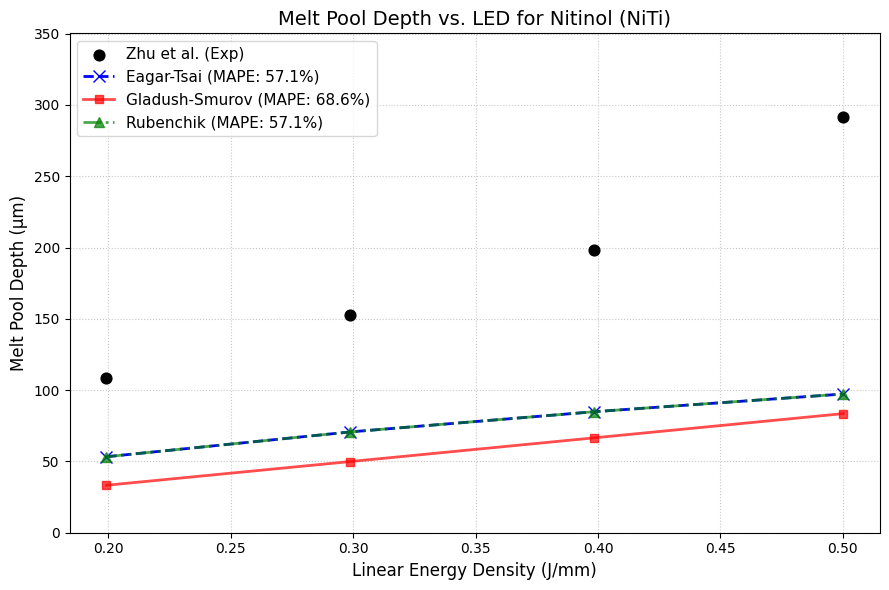

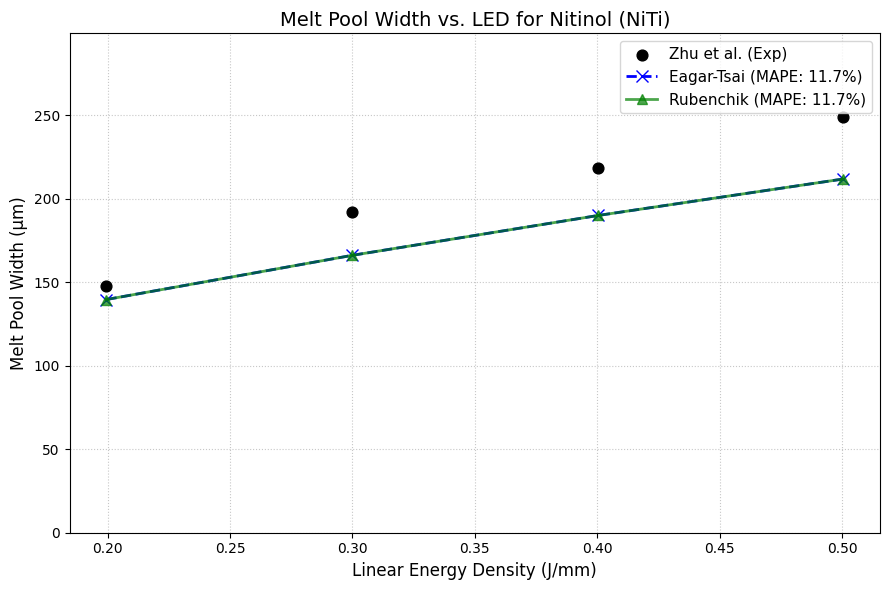

In [4]:
# Cell 5: Metrics & Visualization (Separate Plots)

# --- Error Metrics (MAPE) ---
exp_depths = zhu_depth['Measured_Depth'].values
exp_widths = zhu_width['Measured_Width'].values

# Calculate Mean Absolute Percentage Error (MAPE)
mape_et_depth = np.mean(np.abs((exp_depths - np.array(et_depths)) / exp_depths)) * 100
mape_gs_depth = np.mean(np.abs((exp_depths - np.array(gs_depths)) / exp_depths)) * 100
mape_rub_depth = np.mean(np.abs((exp_depths - np.array(rub_depths)) / exp_depths)) * 100

mape_et_width = np.mean(np.abs((exp_widths - np.array(et_widths)) / exp_widths)) * 100
mape_rub_width = np.mean(np.abs((exp_widths - np.array(rub_widths)) / exp_widths)) * 100

print("--- Depth MAPE ---")
print(f"Eagar-Tsai:     {mape_et_depth:.1f}%")
print(f"Gladush-Smurov: {mape_gs_depth:.1f}%")
print(f"Rubenchik:      {mape_rub_depth:.1f}%")
print("\n--- Width MAPE ---")
print(f"Eagar-Tsai:     {mape_et_width:.1f}%")
print(f"Rubenchik:      {mape_rub_width:.1f}%")

# ==========================================
# Figure 1: Melt Pool Depth Comparison
# ==========================================
plt.figure(figsize=(9, 6))
plt.scatter(zhu_depth['LED'], exp_depths, color='black', marker='o', s=60, label='Zhu et al. (Exp)', zorder=3)
plt.plot(zhu_depth['LED'], et_depths, linestyle='--', color='blue', marker='x', markersize=8, lw=2, label=f'Eagar-Tsai (MAPE: {mape_et_depth:.1f}%)')
plt.plot(zhu_depth['LED'], gs_depths, linestyle='-', color='red', marker='s', markersize=6, lw=2, alpha=0.7, label=f'Gladush-Smurov (MAPE: {mape_gs_depth:.1f}%)')
plt.plot(zhu_depth['LED'], rub_depths, linestyle='-.', color='green', marker='^', markersize=7, lw=2, alpha=0.7, label=f'Rubenchik (MAPE: {mape_rub_depth:.1f}%)')

plt.xlabel('Linear Energy Density (J/mm)', fontsize=12)
plt.ylabel('Melt Pool Depth (μm)', fontsize=12)
plt.ylim(0, max(max(exp_depths), max(gs_depths), max(rub_depths), max(et_depths))*1.2)
plt.title('Melt Pool Depth vs. LED for Nitinol (NiTi)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# ==========================================
# Figure 2: Melt Pool Width Comparison
# ==========================================
plt.figure(figsize=(9, 6))
plt.scatter(zhu_width['LED'], exp_widths, color='black', marker='o', s=60, label='Zhu et al. (Exp)', zorder=3)
plt.plot(zhu_width['LED'], et_widths, linestyle='--', color='blue', marker='x', markersize=8, lw=2, label=f'Eagar-Tsai (MAPE: {mape_et_width:.1f}%)')
plt.plot(zhu_width['LED'], rub_widths, linestyle='-', color='green', marker='^', markersize=7, lw=2, alpha=0.7, label=f'Rubenchik (MAPE: {mape_rub_width:.1f}%)')

plt.xlabel('Linear Energy Density (J/mm)', fontsize=12)
plt.ylabel('Melt Pool Width (μm)', fontsize=12)
plt.ylim(0, max(max(exp_widths), max(rub_widths), max(et_widths))*1.2)  # Set y-axis limit for better visualization
plt.title('Melt Pool Width vs. LED for Nitinol (NiTi)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()